# **Importing Packages**

In [1]:
# Let's start with importing packages
import pandas  as pd

import numpy as np
import matplotlib.pyplot  as plt

import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.simplefilter("ignore")

# **Reading Data**

In [2]:
## Let's create a function for loading the data to pandas dataframe
def process_data(dataframe_path, data='training_data'):
    df = pd.read_csv(dataframe_path) # makes the copy of incoming dataframe
    if data!="training_data":
        # test data won't have labels so returning 
        df = df.values.reshape(-1, 28, 28, 1)
        return df
    
    labels = df.pop("label") # pop function removes the label and assign it to labels variable
    labels = tf.keras.utils.to_categorical(labels, num_classes=10, dtype='float32')
    
    df = df.values.reshape(-1, 28, 28, 1)
    return df, labels

In [3]:
# Path of the datas
train_data_path = "../input/digit-recognizer/train.csv"
test_data_path = "../input/digit-recognizer/test.csv"

In [4]:
train_x, train_y = process_data(train_data_path, data='training_data')
test_x = process_data(test_data_path, data="testing_data")

# **How is the data?**

DATA WITHOUT AGUMENTATION


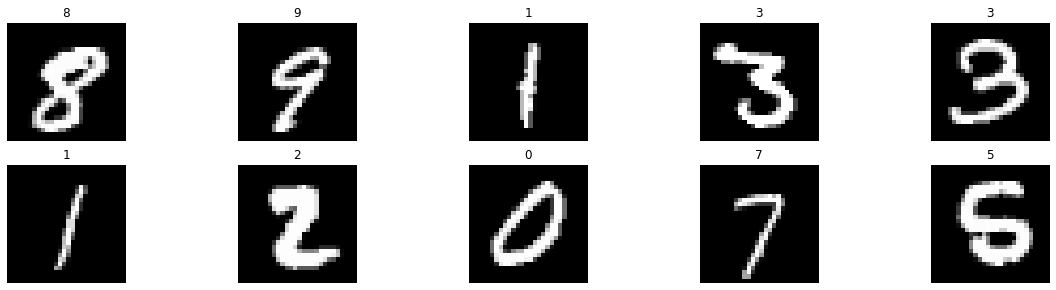

In [5]:
plt.figure(figsize=(20, 10))
print("DATA WITHOUT AGUMENTATION")
for i in range(20):
    plt.subplot(4,5, i%10+1)
    plt.imshow(train_x[i], cmap="gray")
    plt.title(str(np.argmax([train_y[i]])))
    plt.axis('off')

In [6]:
# Loading the data to ImageDataGenerator class and agumenting them
train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=30, # Rotates the image within 30 degree ramdomly
    shear_range=0.1,
    zoom_range=[0.8, 1.0], # Randomly zooms the images
    rescale=1.0/255, # normalizes the data
    validation_split=0.2
)

valid_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255, # normalizes the data
    validation_split=0.2
)

train_generator = train_gen.flow(train_x, train_y, shuffle=True, batch_size=32)
valid_generator = valid_gen.flow(train_x, train_y, shuffle=False, batch_size=32)

In [7]:
img, labels = next(train_generator)

DATA AFTER APPLYING random zooming, rotating [AGUMENTATING]


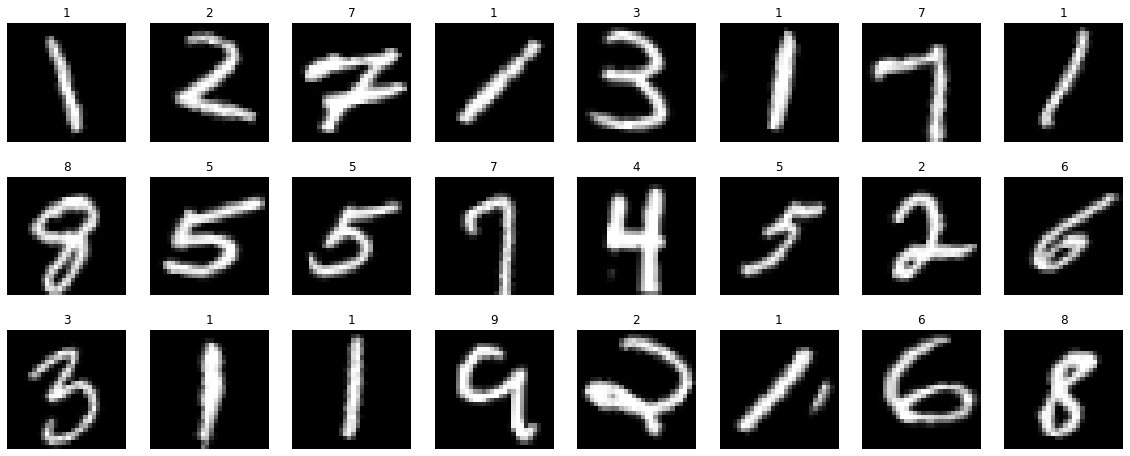

In [8]:
plt.figure(figsize=(20, 8))
print("DATA AFTER APPLYING random zooming, rotating [AGUMENTATING]")
for i in range(24):
    plt.subplot(3,8, i%24+1)
    plt.imshow(img[i], cmap="gray")
    plt.title(str(np.argmax([labels[i]])))
    plt.axis('off')

# **BUILDING MODEL**

In [17]:
# importing packages for model
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

In [27]:
def build_model():
    model = tf.keras.Sequential()

    model.add(Conv2D(8, (5,5), input_shape=[28,28,1], activation='relu'))
    model.add(Conv2D(8, (3,3), padding='SAME', activation='relu'))
    model.add(MaxPooling2D())
    
    model.add(BatchNormalization(axis=-1))
    model.add(Conv2D(16, (3,3), padding='SAME', activation='relu'))
    model.add(MaxPooling2D())

    model.add(BatchNormalization(axis=-1))
    model.add(Conv2D(16, (3,3), padding='SAME', activation='relu'))
    model.add(Conv2D(32, (3,3), padding='SAME', activation='relu'))
    model.add(MaxPooling2D())

    model.add(BatchNormalization(axis=-1))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    # Compiling the model
    model.compile(optimizer=Adam(learning_rate=0.0005), loss=CategoricalCrossentropy(), metrics=['accuracy'])
    
    return model

In [28]:
# Summary of the model
models = {}

models[0] = build_model()
models[1] = build_model()
models[2] = build_model()
models[3] = build_model()

models[0].summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_25 (Conv2D)           (None, 24, 24, 8)         208       
_________________________________________________________________
conv2d_26 (Conv2D)           (None, 24, 24, 8)         584       
_________________________________________________________________
max_pooling2d_15 (MaxPooling (None, 12, 12, 8)         0         
_________________________________________________________________
batch_normalization_9 (Batch (None, 12, 12, 8)         32        
_________________________________________________________________
conv2d_27 (Conv2D)           (None, 12, 12, 16)        1168      
_________________________________________________________________
max_pooling2d_16 (MaxPooling (None, 6, 6, 16)          0         
_________________________________________________________________
batch_normalization_10 (Batc (None, 6, 6, 16)         

In [30]:
# Train the model by uncommenting
for i in range(4):
    print("\nTraining model 1\n")
    models[i].fit(train_generator, validation_data=valid_generator, epochs=10)


Training model 1

Epoch 1/10
1313/1313 [==============================] - 20s 15ms/step - loss: 0.6547 - accuracy: 0.7933 - val_loss: 0.1259 - val_accuracy: 0.9607
Epoch 2/10
1313/1313 [==============================] - 19s 15ms/step - loss: 0.1126 - accuracy: 0.9662 - val_loss: 0.0678 - val_accuracy: 0.9794
Epoch 3/10
1313/1313 [==============================] - 20s 15ms/step - loss: 0.0780 - accuracy: 0.9746 - val_loss: 0.0575 - val_accuracy: 0.9819
Epoch 4/10
1313/1313 [==============================] - 19s 14ms/step - loss: 0.0651 - accuracy: 0.9790 - val_loss: 0.0537 - val_accuracy: 0.9829
Epoch 5/10
1313/1313 [==============================] - 19s 15ms/step - loss: 0.0602 - accuracy: 0.9810 - val_loss: 0.0461 - val_accuracy: 0.9852
Epoch 6/10
1313/1313 [==============================] - 20s 15ms/step - loss: 0.0537 - accuracy: 0.9833 - val_loss: 0.0477 - val_accuracy: 0.9847
Epoch 7/10
1313/1313 [==============================] - 19s 14ms/step - loss: 0.0543 - accuracy: 0.9837 -

* The accuracy is about 99% it's neat.
* The loss is 0.2

In [ ]:
# Visualizing the training
stats = pd.DataFrame(history.history)
loss  = stats[['loss', 'val_loss']]
acc = stats[['accuracy', 'val_accuracy']]
loss.plot()
acc.plot()

# **Predicting Test data**

In [34]:
preds = {}
for i in range(4):
    preds[i] = models[i].predict(test_x)    

In [41]:
prediction = preds[0] +  preds[1] + preds[2] + preds[3]
prediction = np.array([np.argmax(x) for x in prediction])

In [42]:
# Creating and saving submission.csv file
submission_file = pd.read_csv('../input/digit-recognizer/sample_submission.csv')
submission_file.Label = prediction
submission_file.to_csv('submission.csv', index=False)